# User's Original Code & EDA


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
print(sklearn.__version__)

from sklearn import svm
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

%pip install scikit-learn


1.9.0
Note: you may need to restart the kernel to use updated packages.


In [2]:
df = pd.read_csv("data/loan.csv") # Modified path to point to data/loan.csv
df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
df.info()
# checking the number of rows and columns
rows, cols = df.shape
print("Rows:", rows)
print("Columns:", cols)
df.shape


<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 83.4 KB
Rows: 614
Columns: 13


(614, 13)

<Axes: >

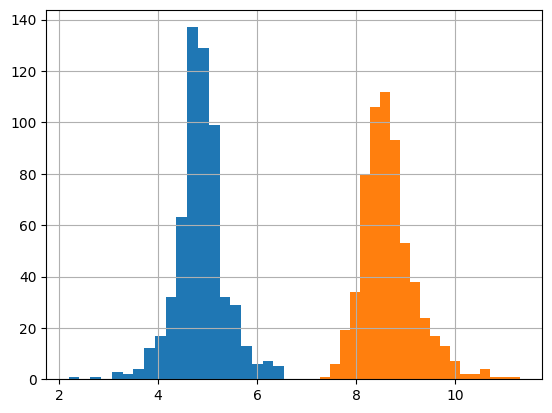

In [4]:
df.isnull().sum()
df['LoanAmount_log']=np.log(df['LoanAmount'])
df['LoanAmount_log'].hist(bins=20)
df.isnull().sum()
df['TotalIncome']= df['ApplicantIncome']+ df['CoapplicantIncome']
df['TotalIncome_log'] = np.log(df['TotalIncome'])
df['TotalIncome_log'].hist(bins=20)


In [5]:
df.replace(r'^\s*$', np.nan, regex=True, inplace=True)

df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].mean())
df['LoanAmount_log'] = df['LoanAmount_log'].fillna(df['LoanAmount_log'].mean())

print(df.isnull().sum())


Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
LoanAmount_log       0
TotalIncome          0
TotalIncome_log      0
dtype: int64


In [6]:
# Categorizing the statistical Data For Loan Approval Prediction System
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
numeric_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term',
                'Credit_History', 'LoanAmount_log', 'TotalIncome_log']

X_encoded = pd.get_dummies(df[categorical_cols], drop_first=True)
X_encoded = pd.concat([X_encoded, df[numeric_cols]], axis=1)

y = df['Loan_Status'].map({'Y': 1, 'N': 0}).values
X = X_encoded.values

print("Encoded feature matrix shape:", X.shape)
print("Sample encoded columns:", X_encoded.columns.tolist()[:10])
df


Encoded feature matrix shape: (614, 16)
Sample encoded columns: ['Gender_Male', 'Married_Yes', 'Dependents_1', 'Dependents_2', 'Dependents_3+', 'Education_Not Graduate', 'Self_Employed_Yes', 'Property_Area_Semiurban', 'Property_Area_Urban', 'ApplicantIncome']


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,LoanAmount_log,TotalIncome,TotalIncome_log
0,LP001002,Male,No,0,Graduate,No,5849,0.0,146.412162,360.0,1.0,Urban,Y,4.857444,5849.0,8.674026
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N,4.852030,6091.0,8.714568
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,Y,4.189655,3000.0,8.006368
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y,4.787492,4941.0,8.505323
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,Y,4.948760,6000.0,8.699515
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.000000,360.0,1.0,Rural,Y,4.262680,2900.0,7.972466
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.000000,180.0,1.0,Rural,Y,3.688879,4106.0,8.320205
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.000000,360.0,1.0,Urban,Y,5.533389,8312.0,9.025456
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.000000,360.0,1.0,Urban,Y,5.231109,7583.0,8.933664


                   count         mean          std          min          25%  \
ApplicantIncome    614.0  5403.459283  6109.041673   150.000000  2877.500000   
CoapplicantIncome  614.0  1621.245798  2926.248369     0.000000     0.000000   
LoanAmount         614.0   146.412162    84.037468     9.000000   100.250000   
Loan_Amount_Term   614.0   342.410423    64.428629    12.000000   360.000000   
Credit_History     614.0     0.855049     0.352339     0.000000     1.000000   
LoanAmount_log     614.0     4.857444     0.495995     2.197225     4.607658   
TotalIncome        614.0  7024.705081  6458.663872  1442.000000  4166.000000   
TotalIncome_log    614.0     8.669414     0.545102     7.273786     8.334712   

                           50%          75%           max  
ApplicantIncome    3812.500000  5795.000000  81000.000000  
CoapplicantIncome  1188.500000  2297.250000  41667.000000  
LoanAmount          129.000000   164.750000    700.000000  
Loan_Amount_Term    360.000000   360.00

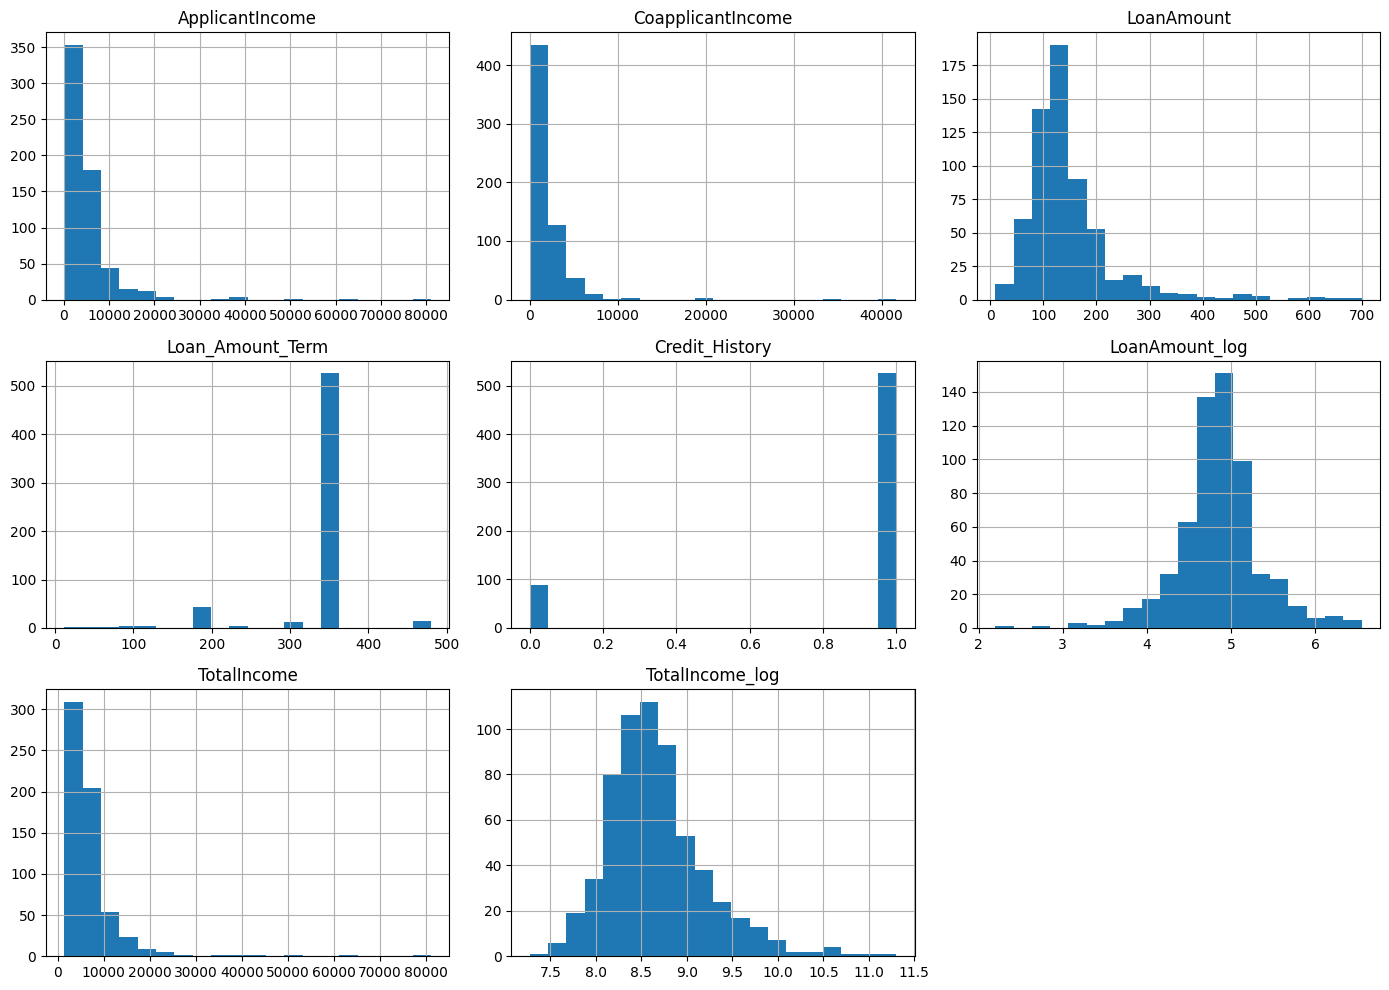

In [7]:
num_cols = df.select_dtypes(include='number').columns
print(df[num_cols].describe().T)

df[num_cols].hist(bins=20, figsize=(14, 10))
plt.tight_layout()
plt.show()


C:\Users\Chandan\AppData\Local\Temp\ipykernel_27948\2150733540.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.drop('Loan_ID')


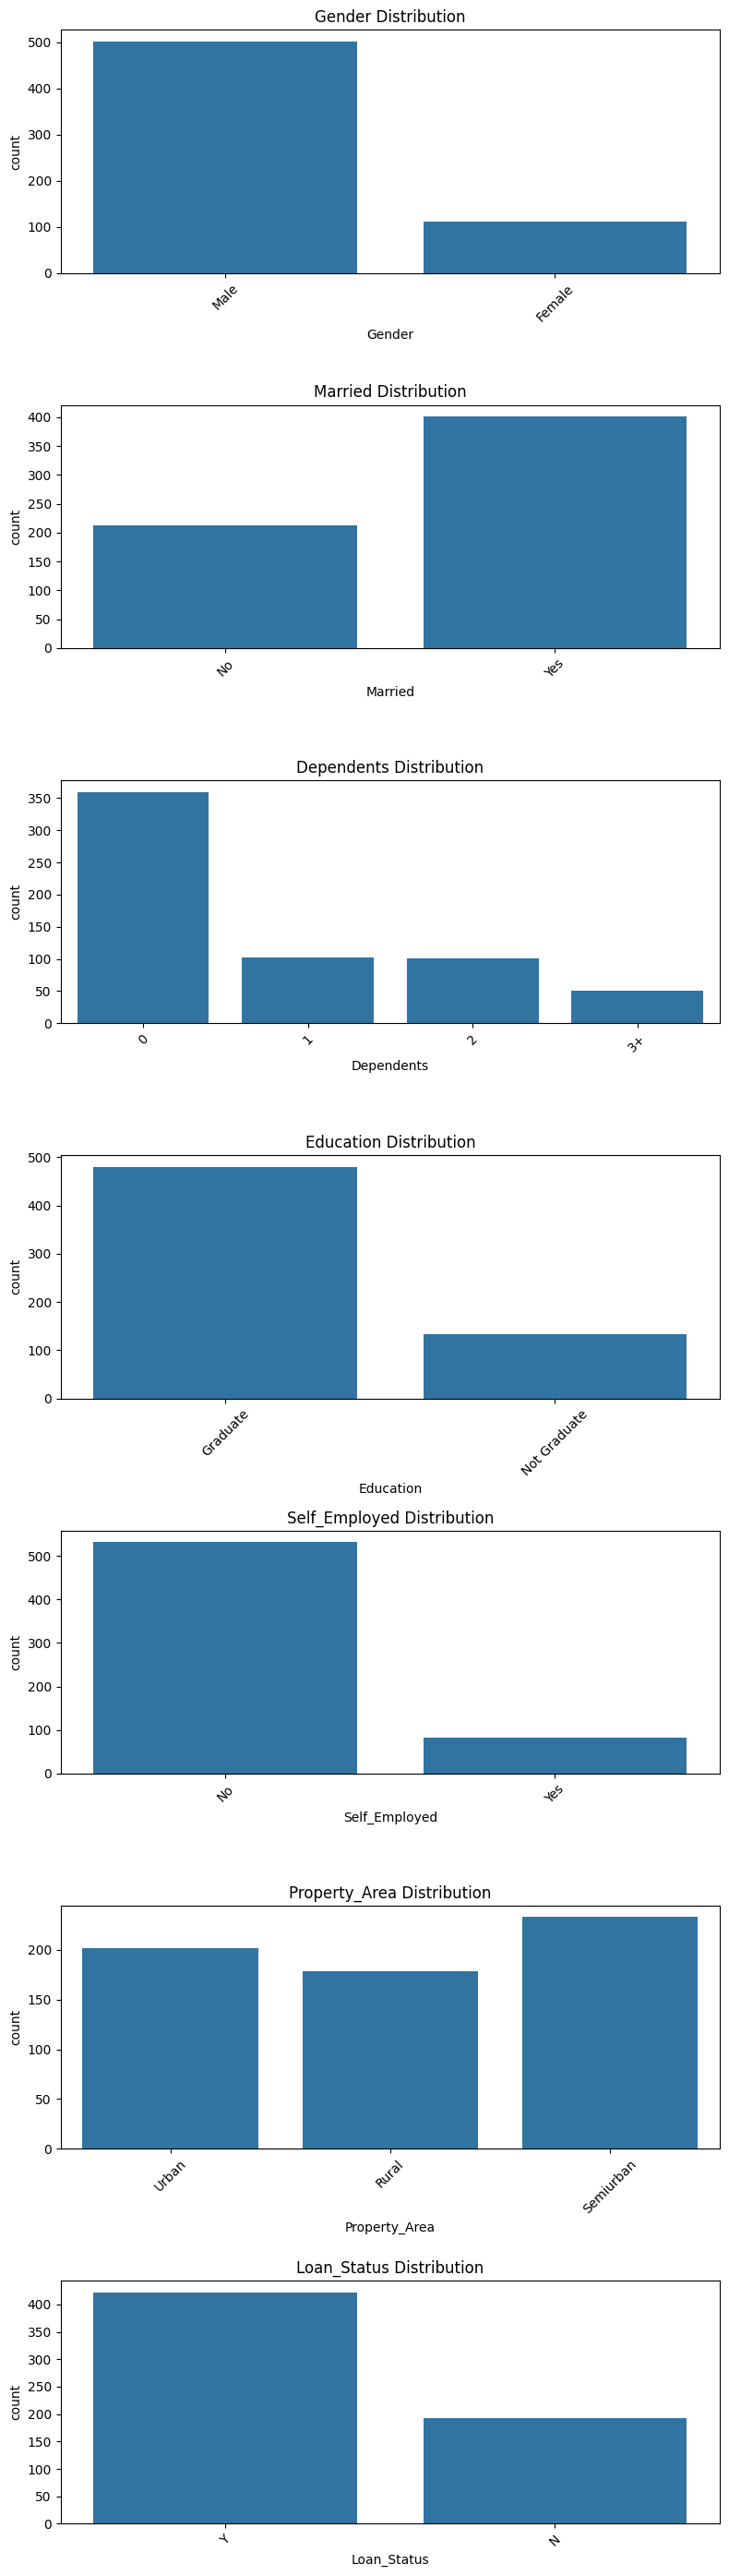

In [8]:
cat_cols = df.select_dtypes(include='object').columns.drop('Loan_ID')

fig, axes = plt.subplots(len(cat_cols), 1, figsize=(8, 4 * len(cat_cols)))

for ax, col in zip(axes, cat_cols):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(f'{col} Distribution')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [9]:
#for training and testing
X = df.drop(columns=['Loan_ID', 'Loan_Status']).to_numpy(dtype=object)
y = df['Loan_Status'].to_numpy(dtype=object)

print('X shape:', X.shape)
print('y shape:', y.shape)

X
y


X shape: (614, 14)
y shape: (614,)


array(['Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'Y', 'Y', 'Y',
       'N', 'Y', 'Y', 'Y', 'N', 'N', 'Y', 'N', 'Y', 'N', 'N', 'N', 'Y',
       'Y', 'Y', 'N', 'Y', 'N', 'N', 'N', 'Y', 'N', 'Y', 'N', 'Y', 'Y',
       'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y',
       'N', 'N', 'N', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'N',
       'N', 'N', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'N', 'N',
       'N', 'Y', 'Y', 'Y', 'N', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'N', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y',
       'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'N',
       'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'Y', 'N', 'N', 'N', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'Y', 'N', 'N', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'N',
       'Y', 'Y', 'Y', 'N', 'Y', 'N', 'Y', 'Y', 'N', 'Y', 'N', 'N

per of missing gender is 0.000000%
number of people who take loan as group by gender: 
Gender
Male      502
Female    112
Name: count, dtype: int64


C:\Users\Chandan\AppData\Local\Temp\ipykernel_27948\302037501.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x ='Gender', data = df, palette='Set1')


<Axes: xlabel='Gender', ylabel='count'>

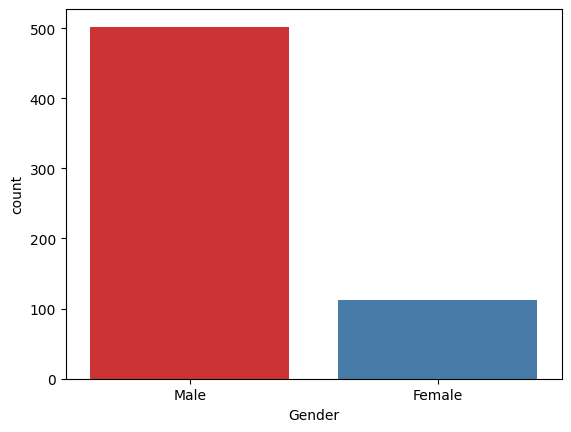

In [10]:
print("per of missing gender is %2f%%" %((df['Gender'].isnull().sum()/df.shape[0])*100))
print("number of people who take loan as group by gender: ")
print(df['Gender'].value_counts())
sns.countplot(x ='Gender', data = df, palette='Set1')


number of people who take loan as group by Marital status: 
Married
Yes    401
No     213
Name: count, dtype: int64


C:\Users\Chandan\AppData\Local\Temp\ipykernel_27948\536817889.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x ='Married', data = df, palette='Set2')


<Axes: xlabel='Married', ylabel='count'>

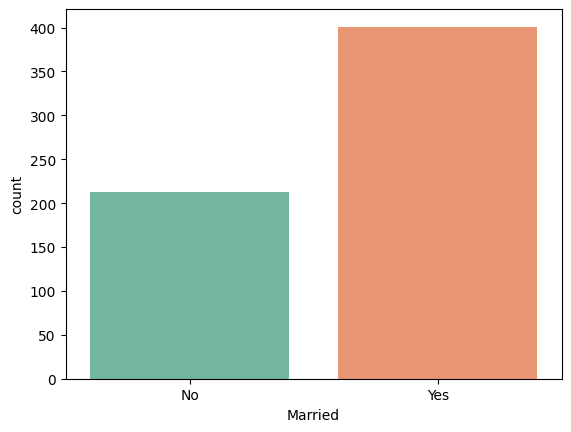

In [11]:
print("number of people who take loan as group by Marital status: ")
print(df['Married'].value_counts())
sns.countplot(x ='Married', data = df, palette='Set2')


number of people who take loan as group by dependents: 
Dependents
0     360
1     102
2     101
3+     51
Name: count, dtype: int64


C:\Users\Chandan\AppData\Local\Temp\ipykernel_27948\2251790220.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x ='Dependents', data = df, palette='Set3')


<Axes: xlabel='Dependents', ylabel='count'>

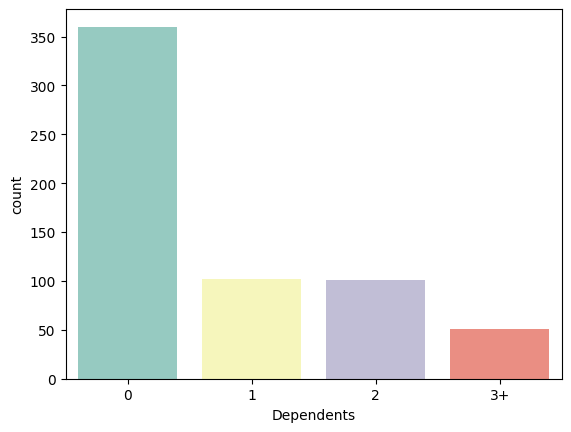

In [12]:
print("number of people who take loan as group by dependents: ")
print(df['Dependents'].value_counts())
sns.countplot(x ='Dependents', data = df, palette='Set3')


number of people who take loan as group by self-employed: 
Self_Employed
No     532
Yes     82
Name: count, dtype: int64


C:\Users\Chandan\AppData\Local\Temp\ipykernel_27948\3085608172.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x ='Self_Employed', data = df, palette='Set1')


<Axes: xlabel='Self_Employed', ylabel='count'>

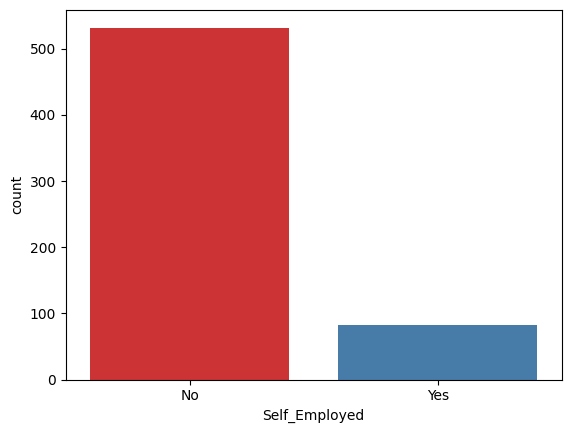

In [13]:
print("number of people who take loan as group by self-employed: ")
print(df['Self_Employed'].value_counts())
sns.countplot(x ='Self_Employed', data = df, palette='Set1')


C:\Users\Chandan\AppData\Local\Temp\ipykernel_27948\2510148696.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x ='LoanAmount', data = df, palette='Set1')


number of people who take loan as group by loanamount: 
LoanAmount
146.412162    22
120.000000    20
110.000000    17
100.000000    15
187.000000    12
              ..
292.000000     1
142.000000     1
350.000000     1
496.000000     1
253.000000     1
Name: count, Length: 204, dtype: int64


<Axes: xlabel='LoanAmount', ylabel='count'>

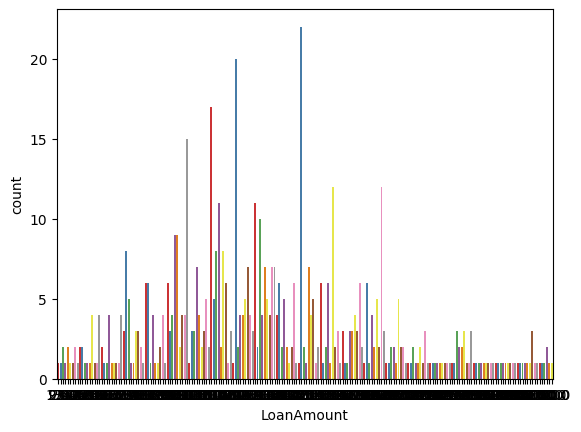

In [14]:
print("number of people who take loan as group by loanamount: ")
print(df['LoanAmount'].value_counts())
sns.countplot(x ='LoanAmount', data = df, palette='Set1')


number of people who take loan as group by Credit history: 
Credit_History
1.0    525
0.0     89
Name: count, dtype: int64


C:\Users\Chandan\AppData\Local\Temp\ipykernel_27948\1612443228.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x ='Credit_History', data = df, palette='Set1')


<Axes: xlabel='Credit_History', ylabel='count'>

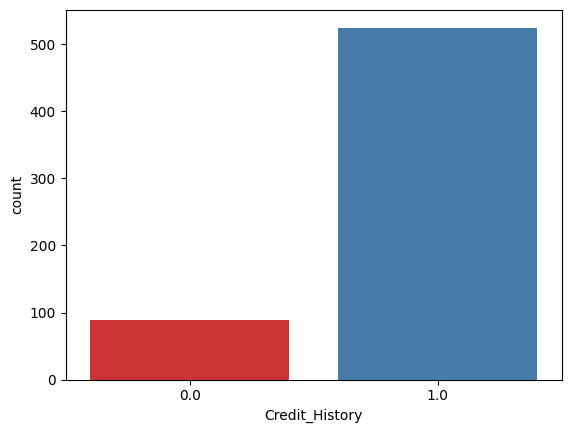

In [15]:
print("number of people who take loan as group by Credit history: ")
print(df['Credit_History'].value_counts())
sns.countplot(x ='Credit_History', data = df, palette='Set1')


In [16]:
#Modeling Using Linear Regression
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.1, random_state=2)

LabelEncoder_x = LabelEncoder()
for i in range(0, 5):
    X_train[:, i] = LabelEncoder_x.fit_transform(X_train[:, i])
    X_train[:, 7] = LabelEncoder_x.fit_transform(X_train[:, 7])
X_train


array([[1, 1, 1, ..., 4.700480365792417, 4022.0, 8.299534570332597],
       [1, 1, 0, ..., 5.1647859739235145, 9862.0, 9.196444266784072],
       [1, 0, 0, ..., 4.736198448394496, 4693.0, 8.453827315794417],
       ...,
       [0, 0, 0, ..., 5.41610040220442, 17263.0, 9.756320761816548],
       [1, 1, 1, ..., 5.081404364984463, 6715.0, 8.812099108957337],
       [1, 0, 0, ..., 4.143134726391533, 2237.0, 7.71289096149013]],
      shape=(552, 14), dtype=object)

In [17]:
LabelEncoder_y = LabelEncoder()
y_train = LabelEncoder_y.fit_transform(np.array(y_train))
y_train


array([0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0,
       0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,

In [18]:
for i in range(0,5):
    X_test[:,i] = LabelEncoder_x.fit_transform(X_test[:,i])
    X_test[:,7] = LabelEncoder_x.fit_transform(X_test[:,7])
X_test


array([[0, 1, 0, 1, 0, 2149, 3237.0, 36, 360.0, 0.0, 'Semiurban',
        5.181783550292085, 5386.0, 8.591558273371545],
       [1, 1, 0, 0, 0, 3166, 2064.0, 15, 360.0, 0.0, 'Urban',
        4.6443908991413725, 5230.0, 8.56216655705897],
       [1, 0, 0, 0, 0, 4095, 3447.0, 29, 360.0, 1.0, 'Rural',
        5.017279836814924, 7542.0, 8.928242677818302],
       [1, 1, 1, 0, 0, 3988, 0.0, 1, 240.0, 1.0, 'Urban',
        3.912023005428146, 3988.0, 8.291045131081729],
       [1, 1, 3, 1, 0, 2071, 754.0, 10, 480.0, 1.0, 'Semiurban',
        4.543294782270004, 2825.0, 7.946263643580541],
       [1, 0, 0, 0, 0, 1926, 1851.0, 1, 360.0, 1.0, 'Semiurban',
        3.912023005428146, 3777.0, 8.236685322712457],
       [0, 0, 1, 0, 0, 3652, 0.0, 11, 360.0, 1.0, 'Semiurban',
        4.553876891600541, 3652.0, 8.20303024171486],
       [1, 1, 0, 0, 0, 3775, 0.0, 18, 360.0, 1.0, 'Semiurban',
        4.700480365792417, 3775.0, 8.236155661683124],
       [1, 1, 1, 0, 1, 7787, 0.0, 42, 360.0, 1.0, 'Urban'

In [19]:
LabelEncoder_y = LabelEncoder()
y_test = LabelEncoder_y.fit_transform(np.array(y_test))
y_test


array([0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1])

In [20]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode Property_Area (column 10)
le = LabelEncoder()
X_train[:, 10] = le.fit_transform(X_train[:, 10])
X_test[:, 10] = le.transform(X_test[:, 10])

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.astype(float))
X_test = scaler.transform(X_test.astype(float))


In [21]:
rf_clf = RandomForestClassifier()
rf_clf.fit(X_train, y_train )
y_pred = rf_clf.predict(X_test)
if len(y_pred) != len(y_test):
    print("Warning: length mismatch y_pred:", len(y_pred), "y_test:", len(y_test))
    acc = metrics.accuracy_score(y_test, y_pred[:len(y_test)])
else:
    acc = metrics.accuracy_score(y_test, y_pred)
print("Acc of random forest clf is", acc)
y_pred


Acc of random forest clf is 0.7580645161290323


array([0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0])

In [22]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

nb_clif = GaussianNB()
nb_clif.fit(X_train, y_train)

y_pred = nb_clif.predict(X_test)
if y_pred.dtype.kind in {'U', 'S', 'O'}:
    y_pred = np.where(y_pred == 'Y', 1, 0)

acc = accuracy_score(y_test, y_pred)
print("Accuracy of GaussianNB:", acc)
print(y_pred)


Accuracy of GaussianNB: 0.8225806451612904
[0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 0 1 0 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1]


In [23]:
#Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dt_clf = DecisionTreeClassifier()
dt_clf.fit(X_train,y_train)

param_grid = {
    'max_depth': [3, 5, 7, 9, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced']
}
grid = GridSearchCV(DecisionTreeClassifier(random_state=2), param_grid, cv=5, n_jobs=-1, scoring='accuracy')
grid.fit(X_train, y_train)
dt_best = grid.best_estimator_
y_pred = dt_best.predict(X_test)

if y_pred.dtype.kind in {'U', 'S', 'O'}:
    y_pred_num = np.where(y_pred == 'Y', 1, 0)
else:
    y_pred_num = y_pred

print("Best params:", grid.best_params_)
print("Acc of Dt is", metrics.accuracy_score(y_test, y_pred_num))
y_pred


Best params: {'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}
Acc of Dt is 0.7741935483870968


array([0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0])

In [24]:
import joblib
import json
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

BASE_DIR = Path().resolve()
MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)

# Define exact features as expected by the UI
CATEGORICAL_FEATURES = [
    "Gender", "Married", "Dependents", "Education",
    "Self_Employed", "Property_Area",
]
NUMERIC_FEATURES = [
    "ApplicantIncome", "CoapplicantIncome", "LoanAmount",
    "Loan_Amount_Term", "Credit_History", "TotalIncome_log",
]
TARGET = "Loan_Status"

X_ui = df[CATEGORICAL_FEATURES + NUMERIC_FEATURES]
y_ui = df[TARGET].map({"Y": 1, "N": 0})

X_train_ui, X_test_ui, y_train_ui, y_test_ui = train_test_split(
    X_ui, y_ui, test_size=0.2, random_state=42, stratify=y_ui
)

preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), NUMERIC_FEATURES),
])

ui_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, class_weight="balanced"),
    "Naive Bayes": GaussianNB()
}

metrics_dict = {}
cms = {}
trained_pipelines = {}


In [25]:
for name, clf in ui_models.items():
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", clf)])
    pipeline.fit(X_train_ui, y_train_ui)
    y_pred_ui = pipeline.predict(X_test_ui)
    
    acc = accuracy_score(y_test_ui, y_pred_ui)
    prec = precision_score(y_test_ui, y_pred_ui)
    rec = recall_score(y_test_ui, y_pred_ui)
    f1 = f1_score(y_test_ui, y_pred_ui)
    cm = confusion_matrix(y_test_ui, y_pred_ui)
    
    trained_pipelines[name] = pipeline
    cms[name] = cm
    metrics_dict[name] = {
        "accuracy": round(acc, 4),
        "precision": round(prec, 4),
        "recall": round(rec, 4),
        "f1_score": round(f1, 4),
        "n_train": int(len(X_train_ui)),
        "n_test": int(len(X_test_ui))
    }
    
    print(f"--- {name} (UI Model) ---")
    print(f"Accuracy: {acc:.4f} | F1: {f1:.4f}")
    joblib.dump(pipeline, MODEL_DIR / f"{name.lower().replace(' ', '_')}.joblib")
    
with open(MODEL_DIR / "metrics.json", "w") as f:
    json.dump(metrics_dict, f, indent=2)


--- Logistic Regression (UI Model) ---
Accuracy: 0.8618 | F1: 0.9081


--- Random Forest (UI Model) ---
Accuracy: 0.8374 | F1: 0.8851
--- Naive Bayes (UI Model) ---
Accuracy: 0.8455 | F1: 0.8962


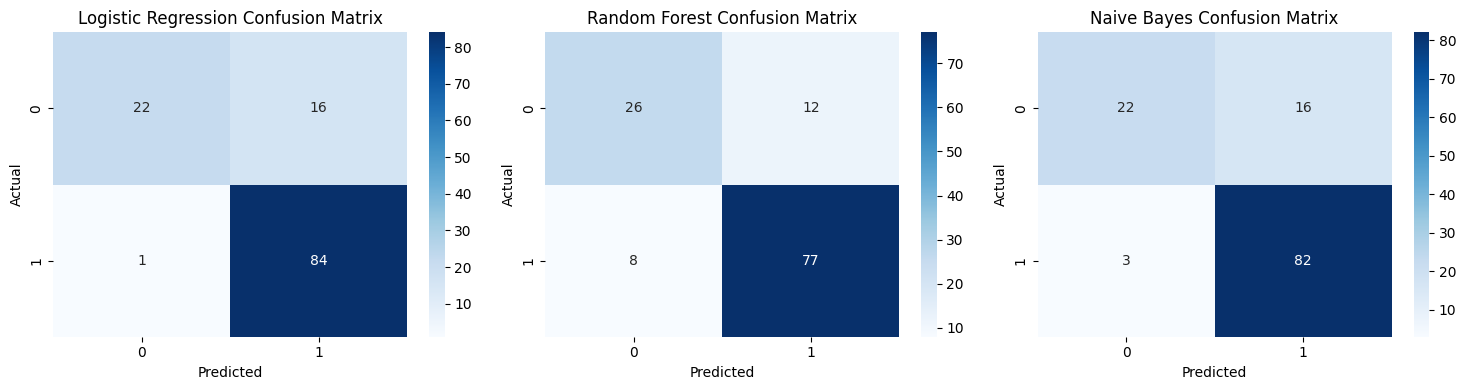

In [26]:
# 1. Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, cm) in zip(axes, cms.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(MODEL_DIR / "confusion_matrices.png")
plt.show()


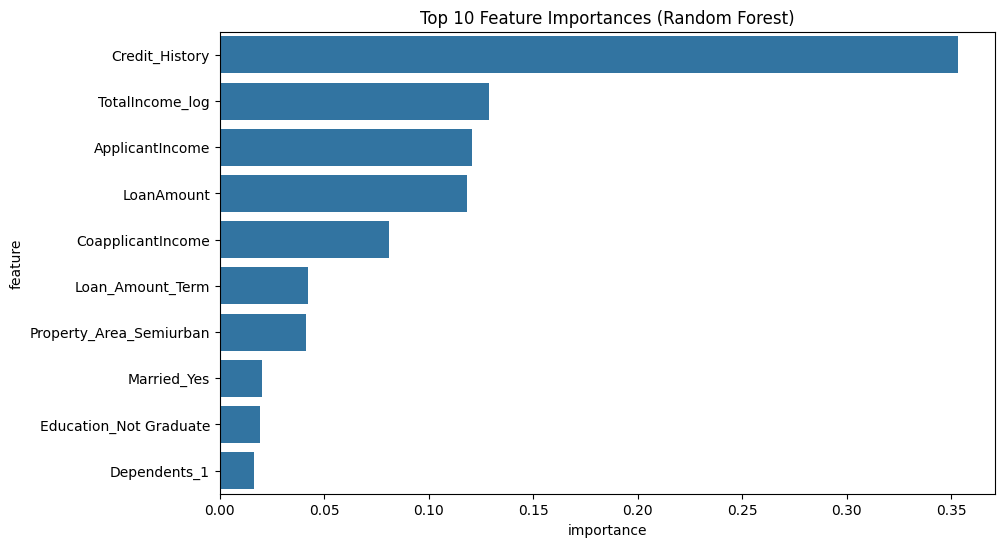

In [27]:
# 2. Feature Importances (Random Forest)
encoded_cat_names = trained_pipelines["Random Forest"].named_steps["preprocessor"] \
    .named_transformers_["cat"].get_feature_names_out(CATEGORICAL_FEATURES)
all_feature_names = list(encoded_cat_names) + NUMERIC_FEATURES

rf_importances = trained_pipelines["Random Forest"].named_steps["classifier"].feature_importances_

feat_imp_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": rf_importances,
}).sort_values("importance", ascending=False).reset_index(drop=True)

feat_imp_df.to_csv(MODEL_DIR / "feature_importance.csv", index=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=feat_imp_df.head(10))
plt.title("Top 10 Feature Importances (Random Forest)")
plt.savefig(MODEL_DIR / "feature_importance.png")
plt.show()


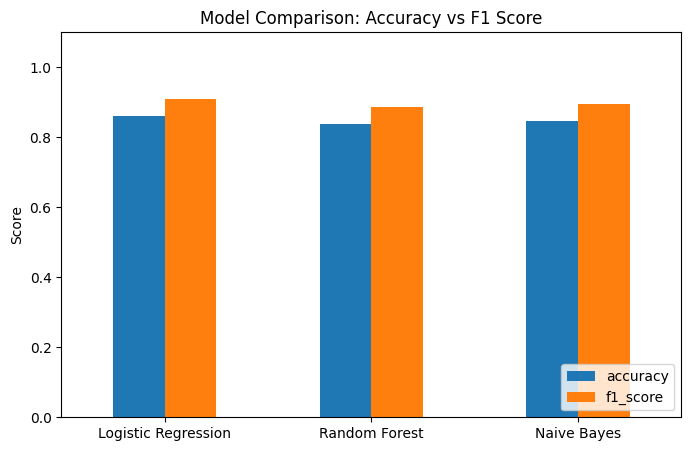

In [28]:
# 3. Model Comparison Bar Chart (Accuracy vs F1 Score)
metrics_df = pd.DataFrame(metrics_dict).T[['accuracy', 'f1_score']]
metrics_df.plot(kind='bar', figsize=(8, 5))
plt.title("Model Comparison: Accuracy vs F1 Score")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.savefig(MODEL_DIR / "model_comparison.png")
plt.show()
